<a href="https://colab.research.google.com/github/Alramadhanny/Abdullah-Al-Ramadhani_2411533016_ML2526/blob/main/Latihan_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/Dataset/advertising (1).csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

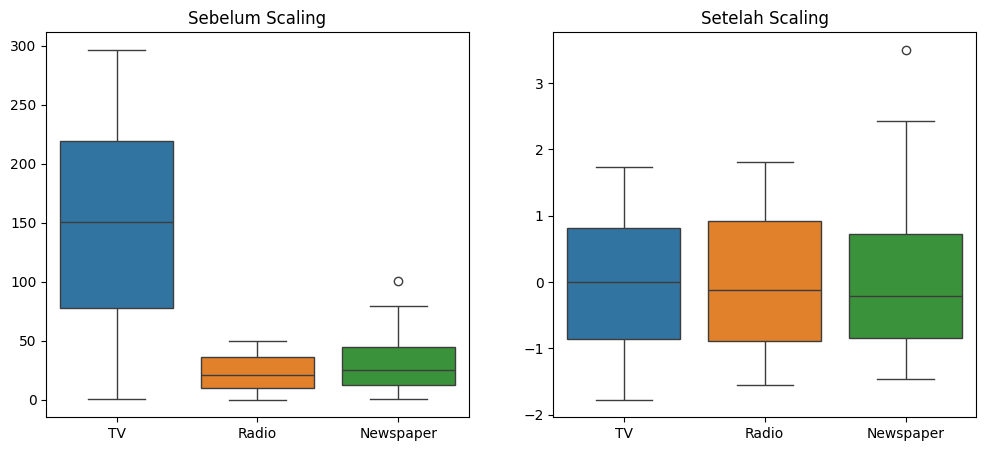

In [5]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=X_train[['TV','Radio','Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV','Radio','Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients: [4.58720774 1.48984025 0.08791597]


In [7]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients: [4.55913661 1.48074139 0.0914114 ]


In [8]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print("\nLasso Regression (alpha=0.1)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso.coef_)


Lasso Regression (alpha=0.1)
RMSE Train: 1.643031487122971
RMSE Test : 1.7117675228539946
Coefficients: [4.49218143 1.42301597 0.01566227]


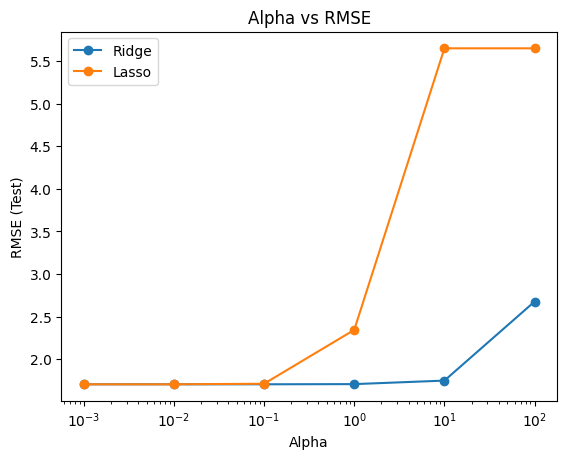

In [9]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

2A. Apakah Ridge menurunkan gap RMSE antara train dan test?

In [15]:
gap_lr = abs(rmse_test_lr - rmse_train_lr)

ridge_metrics = {
    "Alpha": alphas,
    "RMSE Train Ridge": [],
    "RMSE Test Ridge": [],
    "Gap RMSE Ridge": []
}

for val in alphas:
    model = Ridge(alpha=val).fit(X_train_scaled, y_train)

    train_err = np.sqrt(mean_squared_error(y_train, model.predict(X_train_scaled)))
    test_err = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled)))

    ridge_metrics["RMSE Train Ridge"].append(train_err)
    ridge_metrics["RMSE Test Ridge"].append(test_err)
    ridge_metrics["Gap RMSE Ridge"].append(abs(test_err - train_err))

df_ridge = pd.DataFrame(ridge_metrics)

print("Gap RMSE Linear Regression")
print(f"RMSE Train Linear Regression: {rmse_train_lr}")
print(f"RMSE Test Linear Regression : {rmse_test_lr}")
print(f"Gap Linear Regression       : {gap_lr}\n")

print("Gap RMSE Ridge Regression")
display(df_ridge)

improved_ridge = df_ridge[df_ridge["Gap RMSE Ridge"] < gap_lr]

print("\nJawaban Poin A:")
if not improved_ridge.empty:
    print("Ya, Ridge menurunkan gap RMSE pada beberapa nilai alpha.")
    print("Alpha yang menghasilkan gap lebih kecil dari Linear Regression:")
    display(improved_ridge)
else:
    print("Tidak, Ridge belum menurunkan gap RMSE dibandingkan Linear Regression.")

Gap RMSE Linear Regression
RMSE Train Linear Regression: 1.6358920055378559
RMSE Test Linear Regression : 1.7052146229349234
Gap Linear Regression       : 0.06932261739706758

Gap RMSE Ridge Regression


,Alpha,RMSE Train Ridge,RMSE Test Ridge,Gap RMSE Ridge
0,0.001,1.635892,1.705217,0.069325
1,0.010,1.635892,1.705234,0.069342
2,0.100,1.635895,1.705412,0.069517
3,1.000,1.636162,1.707430,0.071269
4,10.000,1.659899,1.748760,0.088861
5,100.000,2.466618,2.676301,0.209683



Jawaban Poin A:
Tidak, Ridge belum menurunkan gap RMSE dibandingkan Linear Regression.


In [16]:
l1_metrics = {
    "Alpha": alphas,
    "Koefisien TV": [],
    "Koefisien Radio": [],
    "Koefisien Newspaper": [],
    "Jumlah Koefisien Nol": []
}

for val in alphas:
    model_l1 = Lasso(alpha=val, max_iter=10000).fit(X_train_scaled, y_train)

    l1_metrics["Koefisien TV"].append(model_l1.coef_[0])
    l1_metrics["Koefisien Radio"].append(model_l1.coef_[1])
    l1_metrics["Koefisien Newspaper"].append(model_l1.coef_[2])
    l1_metrics["Jumlah Koefisien Nol"].append(sum(abs(c) <= 1e-6 for c in model_l1.coef_))

df_lasso = pd.DataFrame(l1_metrics)

print("Koefisien Lasso Regression")
display(df_lasso)

hasil_nol = df_lasso[df_lasso["Jumlah Koefisien Nol"] > 0]

print("\nJawaban Poin B:")
if not hasil_nol.empty:
    print("Ya, Lasso membuat beberapa koefisien menjadi nol pada alpha tertentu.")
    print("Alpha yang menghasilkan koefisien nol:")
    display(hasil_nol)
else:
    print("Tidak, pada nilai alpha yang diuji Lasso belum membuat koefisien menjadi nol.")

Koefisien Lasso Regression


,Alpha,Koefisien TV,Koefisien Radio,Koefisien Newspaper,Jumlah Koefisien Nol
0,0.001,4.586252,1.489189,0.087187,0
1,0.010,4.577701,1.483172,0.080685,0
2,0.100,4.492181,1.423016,0.015662,0
3,1.000,3.638166,0.575085,0.000000,1
4,10.000,0.000000,0.000000,0.000000,3
5,100.000,0.000000,0.000000,0.000000,3



Jawaban Poin B:
Ya, Lasso membuat beberapa koefisien menjadi nol pada alpha tertentu.
Alpha yang menghasilkan koefisien nol:


,Alpha,Koefisien TV,Koefisien Radio,Koefisien Newspaper,Jumlah Koefisien Nol
3,1.0,3.638166,0.575085,0.0,1
4,10.0,0.000000,0.000000,0.0,3
5,100.0,0.000000,0.000000,0.0,3


In [17]:
model_names = ["Linear Regression"]
alpha_vals = [0]
train_rmses = [rmse_train_lr]
test_rmses = [rmse_test_lr]

for val in alphas:
    r_model = Ridge(alpha=val).fit(X_train_scaled, y_train)
    model_names.append("Ridge Regression")
    alpha_vals.append(val)
    train_rmses.append(np.sqrt(mean_squared_error(y_train, r_model.predict(X_train_scaled))))
    test_rmses.append(np.sqrt(mean_squared_error(y_test, r_model.predict(X_test_scaled))))

    l_model = Lasso(alpha=val, max_iter=10000).fit(X_train_scaled, y_train)
    model_names.append("Lasso Regression")
    alpha_vals.append(val)
    train_rmses.append(np.sqrt(mean_squared_error(y_train, l_model.predict(X_train_scaled))))
    test_rmses.append(np.sqrt(mean_squared_error(y_test, l_model.predict(X_test_scaled))))

df_eval = pd.DataFrame({
    "Model": model_names,
    "Alpha": alpha_vals,
    "RMSE Train": train_rmses,
    "RMSE Test": test_rmses
})

print("Semua Hasil RMSE")
display(df_eval)

idx_min = df_eval["RMSE Test"].idxmin()

print("\nJawaban Poin C:")
print("RMSE test paling kecil diperoleh oleh:")
print(f"Model     : {df_eval.loc[idx_min, 'Model']}")
print(f"Alpha     : {df_eval.loc[idx_min, 'Alpha']}")
print(f"RMSE Test : {df_eval.loc[idx_min, 'RMSE Test']}")

Semua Hasil RMSE


,Model,Alpha,RMSE Train,RMSE Test
0,Linear Regression,0.000,1.635892,1.705215
1,Ridge Regression,0.001,1.635892,1.705217
2,Lasso Regression,0.001,1.635893,1.705184
3,Ridge Regression,0.010,1.635892,1.705234
4,Lasso Regression,0.010,1.635964,1.705030
5,Ridge Regression,0.100,1.635895,1.705412
6,Lasso Regression,0.100,1.643031,1.711768
7,Ridge Regression,1.000,1.636162,1.707430
8,Lasso Regression,1.000,2.140203,2.343866
9,Ridge Regression,10.000,1.659899,1.748760



Jawaban Poin C:
RMSE test paling kecil diperoleh oleh:
Model     : Lasso Regression
Alpha     : 0.01
RMSE Test : 1.7050297827636898


In [18]:
max_val = all_results_df["Alpha"].max()

subset_max_alpha = all_results_df[
    (all_results_df["Alpha"] == max_val) &
    (all_results_df["Model"] != "Linear Regression")
]

print("Hasil Model dengan Alpha Terbesar")
display(subset_max_alpha)

print("\nPembanding Linear Regression")
print(f"RMSE Train Linear Regression: {rmse_train_lr}")
print(f"RMSE Test Linear Regression : {rmse_test_lr}")

print("\nJawaban Poin D:")
for item in subset_max_alpha.to_dict("records"):
    is_underfitting = (item["RMSE Train"] > rmse_train_lr) and (item["RMSE Test"] > rmse_test_lr)

    if is_underfitting:
        print(f"{item['Model']} dengan alpha {max_val} kemungkinan mengalami underfitting karena RMSE train dan RMSE test lebih besar dibanding Linear Regression.")
    else:
        print(f"{item['Model']} dengan alpha {max_val} belum menunjukkan underfitting yang kuat.")

Hasil Model dengan Alpha Terbesar


,Model,Alpha,RMSE Train,RMSE Test
6,Ridge Regression,100.0,2.466618,2.676301
12,Lasso Regression,100.0,5.176811,5.648217



Pembanding Linear Regression
RMSE Train Linear Regression: 1.6358920055378559
RMSE Test Linear Regression : 1.7052146229349234

Jawaban Poin D:
Ridge Regression dengan alpha 100.0 kemungkinan mengalami underfitting karena RMSE train dan RMSE test lebih besar dibanding Linear Regression.
Lasso Regression dengan alpha 100.0 kemungkinan mengalami underfitting karena RMSE train dan RMSE test lebih besar dibanding Linear Regression.


Latihan 3

Bagian A

In [19]:
new_alphas = [0.005, 0.05, 0.5, 5, 50]

ridge_new_results = []
lasso_new_results = []

for a in new_alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_new_results.append({
        "Alpha": a,
        "Koefisien TV": ridge.coef_[0],
        "Koefisien Radio": ridge.coef_[1],
        "Koefisien Newspaper": ridge.coef_[2]
    })

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_new_results.append({
        "Alpha": a,
        "Koefisien TV": lasso.coef_[0],
        "Koefisien Radio": lasso.coef_[1],
        "Koefisien Newspaper": lasso.coef_[2]
    })

df_ridge_new = pd.DataFrame(ridge_new_results)
df_lasso_new = pd.DataFrame(lasso_new_results)

print("Hasil Uji Ridge Regression:")
display(df_ridge_new)

print("\nHasil Uji Lasso Regression:")
display(df_lasso_new)

Hasil Uji Ridge Regression:


,Alpha,Koefisien TV,Koefisien Radio,Koefisien Newspaper
0,0.005,4.587067,1.489794,0.087934
1,0.050,4.585796,1.489382,0.088093
2,0.500,4.573129,1.485274,0.089676
3,5.000,4.450205,1.445640,0.104421
4,50.000,3.507528,1.151391,0.182754



Hasil Uji Lasso Regression:


,Alpha,Koefisien TV,Koefisien Radio,Koefisien Newspaper
0,0.005,4.582451,1.486515,0.084297
1,0.050,4.539676,1.456487,0.051767
2,0.500,4.112607,1.049526,0.000000
3,5.000,0.000000,0.000000,0.000000
4,50.000,0.000000,0.000000,0.000000


Bagian B

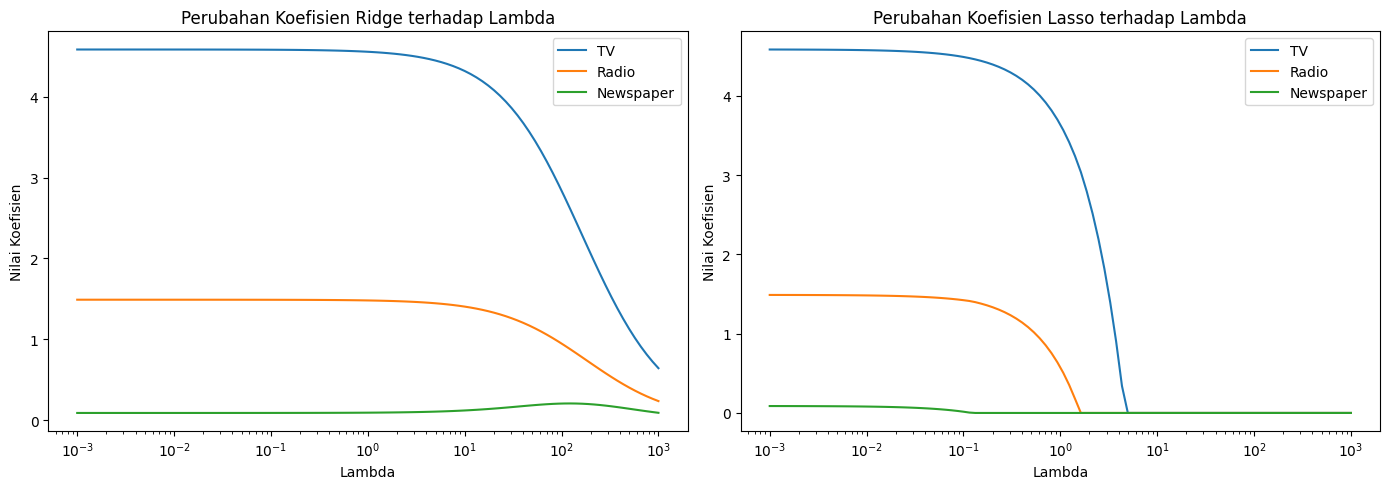

In [20]:
alphas_for_plot = np.logspace(-3, 3, 100)

ridge_coefs = []
lasso_coefs = []

for a in alphas_for_plot:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(alphas_for_plot, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_title('Perubahan Koefisien Ridge terhadap Lambda')
ax[0].set_xlabel('Lambda')
ax[0].set_ylabel('Nilai Koefisien')
ax[0].legend(['TV', 'Radio', 'Newspaper'])

ax[1].plot(alphas_for_plot, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_title('Perubahan Koefisien Lasso terhadap Lambda')
ax[1].set_xlabel('Lambda')
ax[1].set_ylabel('Nilai Koefisien')
ax[1].legend(['TV', 'Radio', 'Newspaper'])

plt.tight_layout()
plt.show()